# Lecture 2 participant notebook: Irreps and the spherical basis

This notebook accompanies Lecture 2, introducing spherical $(\ell,m)$ features and Wigner $D$ matrices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def random_rotation(rng):
    """Return a random proper 3D rotation using a unit quaternion."""
    q = rng.normal(size=4)
    q /= np.linalg.norm(q)
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-z*w),   2*(x*z+y*w)],
        [2*(x*y+z*w),   1-2*(x*x+z*z), 2*(y*z-x*w)],
        [2*(x*z-y*w),   2*(y*z+x*w),   1-2*(x*x+y*y)],
    ])

## 1. Build the basis conversion and $D^{(\ell)}(R)$

Read the function input/output docstrings as you run this block. The final-axis order is always
$m=-\ell,\ldots,+\ell$.

In [3]:
# Spherical basis and Wigner D matrices 
# Shared setup, identical in Lectures 2-5. Lecture 2 walks through it line by
# line; in later lectures just run it and move on.
from sympy.physics.wigner import clebsch_gordan  # Load tabulated CG coefficients from SymPy.

SQ2 = np.sqrt(2.0)  # Store sqrt(2), which appears repeatedly in the spherical basis.
U1 = np.array([  # Define the unitary change of basis from Cartesian (x,y,z) to m=(-1,0,+1).
    [1/SQ2, -1j/SQ2, 0],   # m=-1: v_-1 = (v_x - i v_y)/sqrt(2).
    [0,      0,       1],   # m= 0: v_0  = v_z.
    [-1/SQ2, -1j/SQ2, 0],  # m=+1: v_+1 = -(v_x + i v_y)/sqrt(2).
], dtype=complex)  # Spherical components are complex even for a real Cartesian vector.

def cart_to_sph(v):
    """Convert Cartesian vectors to spherical l=1 components.

    Inputs
    ------
    v : array, shape (..., 3)
        Real or complex vectors whose final axis is ordered (x, y, z).

    Returns
    -------
    array, shape (..., 3)
        Complex spherical components ordered by m=(-1, 0, +1).
    """
    v = np.asarray(v)  # Accept a list or ndarray and preserve any leading batch axes.
    return v @ U1.T  # Apply U1 to the final axis; row-vector storage requires the transpose.

def sph_to_cart(v_sph):
    """Convert spherical l=1 components back to Cartesian vectors.

    Inputs
    ------
    v_sph : array, shape (..., 3)
        Spherical components ordered by m=(-1, 0, +1).

    Returns
    -------
    array, shape (..., 3)
        Cartesian components ordered (x, y, z); physical real vectors become real arrays.
    """
    v_sph = np.asarray(v_sph)  # Accept a list or ndarray and preserve leading axes.
    v_cart = v_sph @ U1.conj()  # Apply U1^dagger; row-vector storage gives U1.conjugate().
    return np.real_if_close(v_cart, tol=1000)  # Remove round-off-sized imaginary parts only.

def cg_tensor(l1, l2, L):
    """Load one Clebsch-Gordan coupling tensor in the spherical basis.

    Inputs
    ------
    l1, l2 : int
        Angular momenta of the two input irreps.
    L : int
        Angular momentum of the coupled output irrep.

    Returns
    -------
    C : complex array, shape (2*L+1, 2*l1+1, 2*l2+1)
        C[M+L,m1+l1,m2+l2] equals <l1 m1,l2 m2 | L M>, including the
        fixed phase that preserves the reality convention for physical tensors.
    """
    C = np.zeros((2*L+1, 2*l1+1, 2*l2+1), dtype=complex)  # Allocate axes (M,m1,m2).
    for M in range(-L, L+1):  # Visit each output magnetic index M=-L,...,+L.
        for m1 in range(-l1, l1+1):  # Visit each magnetic index of the first input.
            m2 = M - m1  # The selection rule M=m1+m2 fixes the second magnetic index.
            if -l2 <= m2 <= l2:  # Skip combinations outside the second irrep's valid range.
                coefficient = clebsch_gordan(l1, l2, L, m1, m2, M)  # Ask SymPy for the CGC.
                C[M+L, m1+l1, m2+l2] = float(coefficient)  # Store it using zero-based indices.
    reality_phase = (-1j)**(l1+l2-L)  # Choose the phase making real inputs map to real tensors.
    return reality_phase * C  # Return fixed representation data, not a learnable parameter.

L_MAX = 2  # Highest irrep this course carries. This is a budget choice, NOT a symmetry
           # rule: the triangle rule genuinely allows 1x2->3 and 2x2->3,4, and we simply
           # do not build them. Raise L_MAX to get them, at rising cost.

CG = {}  # Map every allowed key (l1,l2,L) to its fixed Clebsch-Gordan tensor.
for l1 in range(L_MAX+1):  # Include first-input irreps l1=0,...,L_MAX.
    for l2 in range(l1, L_MAX+1):  # Store only l1<=l2; cg_product handles the reversed order.
        for L in range(abs(l1-l2), min(l1+l2, L_MAX)+1):  # Triangle rule, then truncate at L_MAX.
            CG[(l1, l2, L)] = cg_tensor(l1, l2, L)  # Load this coupling from SymPy once.

def D_sph(l, R):
    """Construct the Wigner D matrix for a 3D rotation.

    Inputs
    ------
    l : int
        Irrep degree; this compact example supports l=0,1,2.
    R : array, shape (3, 3)
        Active Cartesian rotation matrix acting as v_rotated = R @ v.

    Returns
    -------
    D : complex array, shape (2*l+1, 2*l+1)
        Wigner D^l(R), acting on m=-l,...,+l spherical components.
    """
    if l == 0:  # A scalar has one component and is unchanged by every rotation.
        return np.ones((1, 1), dtype=complex)  # D^0(R)=1.
    R = np.asarray(R)  # Normalize the input to an ndarray before matrix multiplication.
    D1 = U1 @ R @ U1.conj().T  # Rewrite the Cartesian rotation in the spherical l=1 basis.
    if l == 1:  # A spherical vector transforms directly with this 3x3 matrix.
        return D1  # Return D^1(R).
    if l == 2:  # Build the five-dimensional irrep from the 1 tensor 1 -> 2 coupling.
        C112 = CG[(1, 1, 2)]  # Fetch the fixed CG tensor selecting total angular momentum L=2.
        return np.einsum('Mab,ai,bj,Nij->MN', C112, D1, D1, C112.conj())  # C (D1 x D1) C^dagger; see Lecture 3
        # the conjugate matters: C(1,1,2) happens to be real, but a coupling whose
        # phase (-i)^(l1+l2-L) is odd is not, and C^T would then be the wrong matrix.
    raise ValueError("this compact example implements l=0,1,2")  # Reject unsupported irreps.

def rotate_sph_features(features, R):
    """Rotate every multiplet in a feature dictionary.

    Inputs
    ------
    features : dict[int, array(batch, channels, 2*l+1)]
        Spherical features grouped by irrep degree l.
    R : array, shape (3, 3)
        Cartesian rotation applied to every sample and channel.

    Returns
    -------
    dict[int, array(batch, channels, 2*l+1)]
        A new dictionary with D^l(R) applied along every magnetic-index axis.
    """
    rotated = {}  # Create a new dictionary so the input features are not modified.
    for l, values in features.items():  # Process each irrep block independently.
        Dl = D_sph(l, R)  # Obtain the correct generalized rotation for this l.
        rotated[l] = np.einsum('mn,bcn->bcm', Dl, values)  # Contract D's input m with the feature m.
    return rotated  # Return all rotated irrep blocks.

v_cart = rng.normal(size=(5, 3))  # Draw five real Cartesian vectors for a round-trip test.
v_reconstructed = sph_to_cart(cart_to_sph(v_cart))  # Convert Cartesian -> spherical -> Cartesian.
roundtrip_error = np.max(np.abs(v_reconstructed - v_cart))  # Compare reconstruction to the original.
print(f"Cartesian <-> spherical round-trip: {roundtrip_error:.1e}")  # Expect floating-point error.

Ra = random_rotation(rng)  # Draw the first rotation used in the representation-law check.
Rb = random_rotation(rng)  # Draw the second rotation used in the representation-law check.
for l in (0, 1, 2):  # Test every irrep implemented in this example.
    hom = np.max(np.abs(D_sph(l, Ra) @ D_sph(l, Rb) - D_sph(l, Ra @ Rb)))  # Check D(Ra)D(Rb)=D(RaRb).
    unit = np.max(np.abs(D_sph(l, Ra) @ D_sph(l, Ra).conj().T - np.eye(2*l+1)))  # Check D D^dagger=I.
    print(f"l={l}: representation {hom:.1e}, unitary {unit:.1e}")  # Both errors should be near 1e-15.

Cartesian <-> spherical round-trip: 2.2e-16
l=0: representation 0.0e+00, unitary 0.0e+00
l=1: representation 2.2e-16, unitary 1.2e-16
l=2: representation 3.3e-16, unitary 2.2e-16


## 2. Rotate through two coordinate systems

The Cartesian and spherical routes should produce the same physical vector.

In [5]:
v = rng.normal(size=3)
R = random_rotation(rng)

route_cartesian = R @ v
route_spherical = sph_to_cart(D_sph(1, R) @ cart_to_sph(v))

print("v:", v)
print("Cartesian route:", route_cartesian)
print("spherical route:", route_spherical)
print("max difference:", np.max(np.abs(route_cartesian-route_spherical)))

v: [-0.15452948 -0.42832782 -0.35213355]
Cartesian route: [-0.26884684 -0.21135779 -0.46302417]
spherical route: [-0.26884684 -0.21135779 -0.46302417]
max difference: 5.551115123125783e-17


## 3. Inspect the representation dimensions

In [7]:
for l in (0, 1, 2):
    Dl = D_sph(l, R)
    print(f"l={l}: D shape={Dl.shape}; expected dimension={2*l+1}")

l=0: D shape=(1, 1); expected dimension=1
l=1: D shape=(3, 3); expected dimension=3
l=2: D shape=(5, 5); expected dimension=5


## 4. See an $\ell=2$ feature rotate

Five components are hard to picture. The Cartesian form of an $\ell=2$ feature is a
symmetric traceless matrix, and its angular pattern turns rigidly under rotation.

symmetric: True   traceless: True
independent components: 6 symmetric - 1 trace = 5, which is 2*2+1
tr(Q^2) is invariant: 0.678117 -> 0.678117
The pattern turns rigidly: no lobe grows or shrinks, because rotation acts inside
the five-dimensional l=2 space and cannot leak into l=0 or l=1.


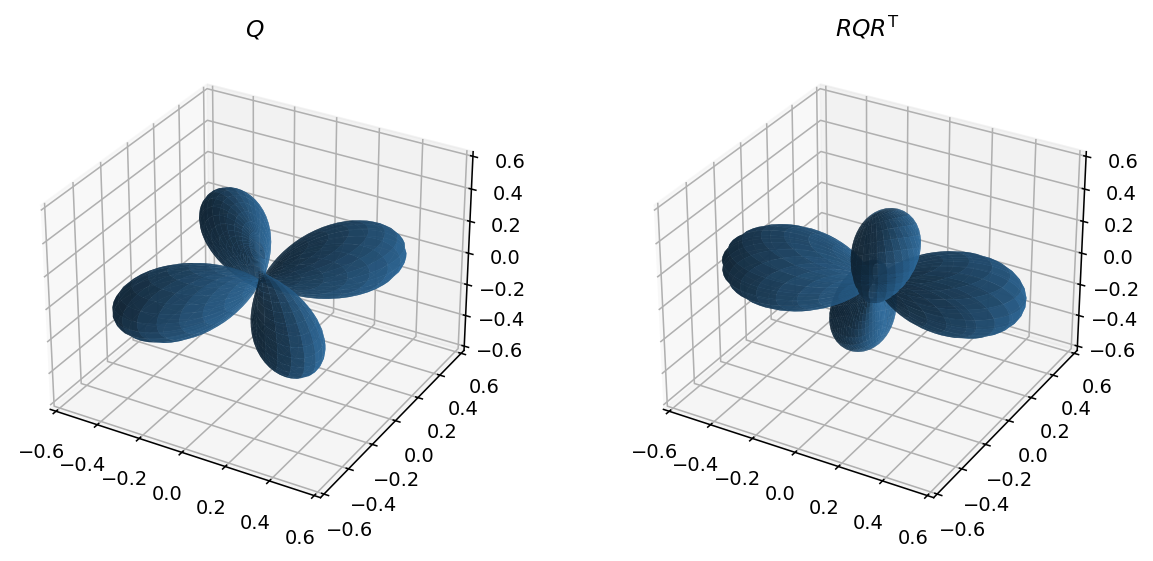

In [9]:
# --- Watch an l=2 object rotate ---------------------------------------------
# The l=2 story is easy to state and hard to picture. In Cartesian form an l=2 feature
# is a symmetric traceless 3x3 matrix Q, which transforms as Q -> R Q R^T. Build one,
# rotate it, and look at the angular pattern n -> |n^T Q n| before and after.
def quadrupole(u, v):
    """Symmetric traceless part of the outer product: the Cartesian l=2 object."""
    Q = 0.5*(np.outer(u, v) + np.outer(v, u))  # Symmetrize the outer product.
    return Q - np.eye(3)*np.trace(Q)/3.0  # Remove the trace, which is the l=0 piece.

u_demo = np.array([1.0, 0.3, -0.2])  # An arbitrary first vector.
v_demo = np.array([0.1, 1.0, 0.4])  # An arbitrary second vector.
Q = quadrupole(u_demo, v_demo)  # Build the quadrupole they span.
R_demo = random_rotation(np.random.default_rng(10))  # One fixed rotation, for reproducibility.
Q_rot = R_demo @ Q @ R_demo.T  # Rotate the whole geometric object.

print("symmetric:", np.allclose(Q, Q.T), "  traceless:", abs(np.trace(Q)) < 1e-12)
print("independent components: 6 symmetric - 1 trace = 5, which is 2*2+1")
print(f"tr(Q^2) is invariant: {np.trace(Q@Q):.6f} -> {np.trace(Q_rot@Q_rot):.6f}")

grid_theta, grid_phi = np.mgrid[0:np.pi:60j, 0:2*np.pi:120j]  # A spherical grid of directions.
n_hat = np.stack([np.sin(grid_theta)*np.cos(grid_phi),  # Unit vectors n(theta,phi), x component.
                  np.sin(grid_theta)*np.sin(grid_phi),  # y component.
                  np.cos(grid_theta)])  # z component.

fig = plt.figure(figsize=(9, 4))  # Two panels: before and after the rotation.
for k, (M, title) in enumerate([(Q, "$Q$"), (Q_rot, "$RQR^\\mathsf{T}$")], 1):
    radius = np.abs(np.einsum('ixy,ij,jxy->xy', n_hat, M, n_hat))  # |n^T M n| in each direction.
    ax = fig.add_subplot(1, 2, k, projection="3d")  # One 3D axis per panel.
    ax.plot_surface(radius*n_hat[0], radius*n_hat[1], radius*n_hat[2],  # Radial angular pattern.
                    rstride=2, cstride=2, color="#2F6FA3", alpha=0.85, linewidth=0)
    lim = float(np.max(radius))  # Use the same scale on all three axes.
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim), title=title)
plt.tight_layout()
plt.show()
print("The pattern turns rigidly: no lobe grows or shrinks, because rotation acts inside")
print("the five-dimensional l=2 space and cannot leak into l=0 or l=1.")

## Try it

1. Verify the spherical reality relation for a real Cartesian vector.
2. Explain why the channel axis is absent from `D_sph`.
3. Modify the round-trip check so that it only checks imaginary residue. Why is that weaker?
4. Generate three rotations and test associativity through their Wigner matrices.